<a href="https://colab.research.google.com/github/202451125/Dog-breed-classification/blob/main/Dog_breed_identification_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**This notebook builds an end-to-end multi-class image classifier using TensorFlow 2.0 and TensorFlow Hub.**

## 1. Problem

Identifying the breed of a dog given an image of a dog.

## 2. Data

The data that I am using is from Kaggle's dog breed identification.

## 3. Evaluation

The evaluation is a file with prediction probabilities for each dog breed of each test image.

## 4.Features

Some information about the data:
* We're dealing with images(unstructed data)
* There are 120 breeds of dogs(this means there are 120 different classes).
* There are around 10,000+ images in the training set and Test set
*Training set has label. while test set do not.



In [ ]:
import os
# This line tells Colab to use the older Keras version compatible with TF Hub
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import tensorflow_hub as hub
import pandas as pd
import numpy as np
# ... any other imports you have

/usr/local/lib/python3.13/dist-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#!unzip "/content/drive/MyDrive/dog_breed_data/d og-breed-identification (2).zip" -d "/content/drive/MyDrive/dog_breed_data"

# Get Our workspace ready!

In [ ]:
import tensorflow as tf
print("TF version", tf.__version__)

TF version 2.21.0


In [ ]:
import tensorflow_hub as hub
print("Tf Hub version:", hub.__version__)

##check for GPU availability
print("GPU", "available (yesss)" if tf.config.list_physical_devices("GPU") else "not available")


Tf Hub version: 0.16.1
GPU not available


## Getting our data ready (turning it into tensors)


In [ ]:
import pandas as pd

labels_csv = pd.read_csv("/content/drive/MyDrive/dog_breed_data/labels.csv")
print(labels_csv.describe())
print(labels_csv.head())

                                      id               breed
count                              10222               10222
unique                             10222                 120
top     fff43b07992508bc822f33d8ffd902ae  scottish_deerhound
freq                                   1                 126
                                 id             breed
0  000bec180eb18c7604dcecc8fe0dba07       boston_bull
1  001513dfcb2ffafc82cccf4d8bbaba97             dingo
2  001cdf01b096e06d78e9e5112d419397          pekinese
3  00214f311d5d2247d5dfe4fe24b2303d          bluetick
4  0021f9ceb3235effd7fcde7f7538ed62  golden_retriever


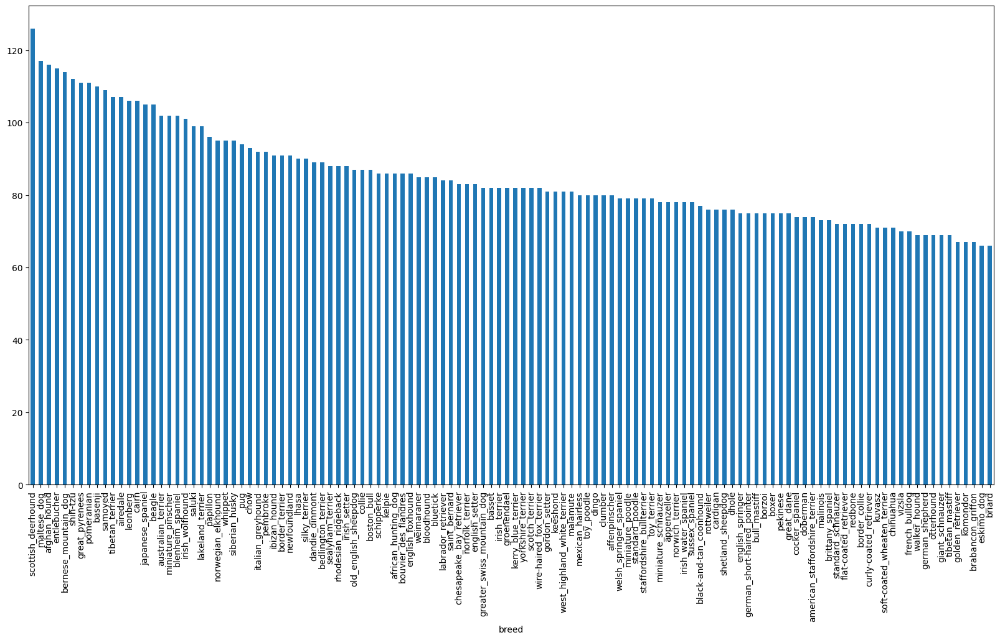

In [ ]:
labels_csv["breed"].value_counts().plot.bar(figsize = (20,10));

In [ ]:
labels_csv["breed"].value_counts().median()

82.0

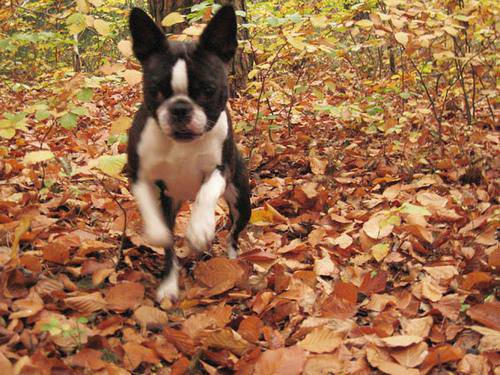

In [ ]:


from IPython.display import Image
Image(filename='/content/drive/MyDrive/dog_breed_data/train/000bec180eb18c7604dcecc8fe0dba07.jpg')


##Getting images and their labels



In [ ]:
labels_csv.head()



,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [ ]:
filenames = ["/content/drive/My Drive/dog_breed_data/train/" + fname for fname in labels_csv["id"]+ ".jpg"]
filenames[:10]

['/content/drive/My Drive/dog_breed_data/train/000bec180eb18c7604dcecc8fe0dba07.jpg',
 '/content/drive/My Drive/dog_breed_data/train/001513dfcb2ffafc82cccf4d8bbaba97.jpg',
 '/content/drive/My Drive/dog_breed_data/train/001cdf01b096e06d78e9e5112d419397.jpg',
 '/content/drive/My Drive/dog_breed_data/train/00214f311d5d2247d5dfe4fe24b2303d.jpg',
 '/content/drive/My Drive/dog_breed_data/train/0021f9ceb3235effd7fcde7f7538ed62.jpg',
 '/content/drive/My Drive/dog_breed_data/train/002211c81b498ef88e1b40b9abf84e1d.jpg',
 '/content/drive/My Drive/dog_breed_data/train/00290d3e1fdd27226ba27a8ce248ce85.jpg',
 '/content/drive/My Drive/dog_breed_data/train/002a283a315af96eaea0e28e7163b21b.jpg',
 '/content/drive/My Drive/dog_breed_data/train/003df8b8a8b05244b1d920bb6cf451f9.jpg',
 '/content/drive/My Drive/dog_breed_data/train/0042188c895a2f14ef64a918ed9c7b64.jpg']

In [ ]:
import os
os.listdir("drive/My Drive/dog_breed_data/train/")[:10]


['e996402cf7fa66f23a8415c9007e06db.jpg',
 'e0f1273a2ed4e1790bd92880d0651893.jpg',
 'e85f6d7af1405365c8e576d0a0aa7a2b.jpg',
 'e2d770fe32772edb9dba937c009f3e4d.jpg',
 'e17f3e7d3d1468c34643e60cb622e935.jpg',
 'dd10fca78ab9624a15f55293c36ad292.jpg',
 'e17462ffe48dffec8ff70325a6047957.jpg',
 'e073b458a33cbfe9b733764a1246f52e.jpg',
 'e3cc185776379b55e23a9973bce785b7.jpg',
 'e66b165e767d45ac2ef046873a27ed29.jpg']

In [ ]:
#Check whether number of filenames matches number of actual image files
import os
if len(os.listdir("drive/My Drive/dog_breed_data/train/")) == len(filenames):
  print("Filenames match actual amount of files !! Proceed")
else:
  print("Filenames doesnot match actual number of files, check the target directory")

Filenames match actual amount of files !! Proceed


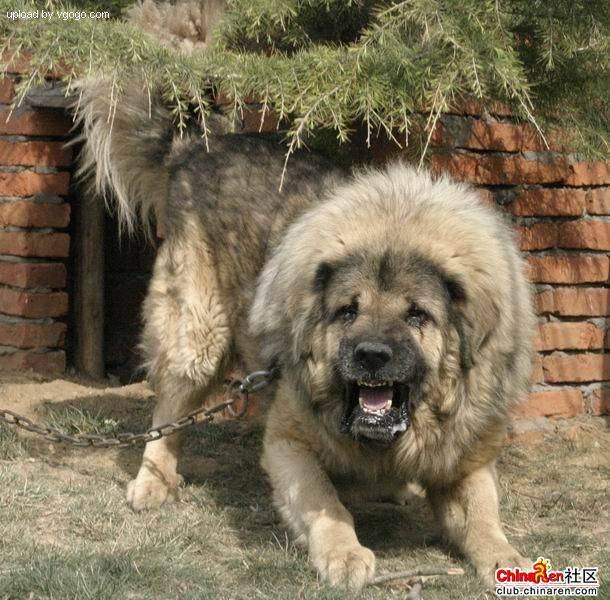

In [ ]:
current_id_at_9000 = labels_csv["id"].iloc[9000]
correct_filename = f"/content/drive/My Drive/dog_breed_data/train/{current_id_at_9000}.jpg"
Image(correct_filename)

In [ ]:
labels_csv["breed"][9000]

'tibetan_mastiff'

Since we have our file paths in the list, lets prepare labels.

In [ ]:
import numpy as np
labels = labels_csv["breed"]
labels = np.array(labels)
labels

array(['boston_bull', 'dingo', 'pekinese', ..., 'airedale',
       'miniature_pinscher', 'chesapeake_bay_retriever'], dtype=object)

In [ ]:
len(labels)

10222

In [ ]:
if len(labels) == len(filenames):
  print("yes!! number of labels matches number of files")
else:
  print("no they dont match")

yes!! number of labels matches number of files


In [ ]:
unique_breeds = np.unique(labels)
unique_breeds

array(['affenpinscher', 'afghan_hound', 'african_hunting_dog', 'airedale',
       'american_staffordshire_terrier', 'appenzeller',
       'australian_terrier', 'basenji', 'basset', 'beagle',
       'bedlington_terrier', 'bernese_mountain_dog',
       'black-and-tan_coonhound', 'blenheim_spaniel', 'bloodhound',
       'bluetick', 'border_collie', 'border_terrier', 'borzoi',
       'boston_bull', 'bouvier_des_flandres', 'boxer',
       'brabancon_griffon', 'briard', 'brittany_spaniel', 'bull_mastiff',
       'cairn', 'cardigan', 'chesapeake_bay_retriever', 'chihuahua',
       'chow', 'clumber', 'cocker_spaniel', 'collie',
       'curly-coated_retriever', 'dandie_dinmont', 'dhole', 'dingo',
       'doberman', 'english_foxhound', 'english_setter',
       'english_springer', 'entlebucher', 'eskimo_dog',
       'flat-coated_retriever', 'french_bulldog', 'german_shepherd',
       'german_short-haired_pointer', 'giant_schnauzer',
       'golden_retriever', 'gordon_setter', 'great_dane',
      

In [ ]:
len(unique_breeds)

120

In [ ]:
print(labels[0])
labels[0] == unique_breeds

boston_bull


array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

In [ ]:
#Turn every label into a boolean array
boolean_labels = [label == unique_breeds for label in labels]
boolean_labels

[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 array([False, False, False, False, False, Fal

In [ ]:
len(boolean_labels)

10222

In [ ]:
#Turning boolean array into integers
print(labels[0])
print(np.where(unique_breeds == labels[0]))
print(boolean_labels[0].argmax())
print(boolean_labels[0].astype(int))

boston_bull
(array([19]),)
19
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


In [ ]:
print(labels[2])
print(boolean_labels[2].astype(int))

pekinese
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


##Creating our own validation set

since the dataset from Kaggle doesn't vome with a validation set. we are going to create own own.

In [ ]:
X = filenames
y = boolean_labels

experimenting for 1000 images with images and then increasing as needed.

In [ ]:

NUM_IMAGES = 1000 #@param {type:"slider", min:1000, max:10000}

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X[: NUM_IMAGES], y[:NUM_IMAGES], test_size = 0.2, random_state = 42)

len(X_train), len(X_val), len(y_train), len(y_val)

(800, 200, 800, 200)

In [ ]:
X_train[:2], y_train[:2]

(['/content/drive/My Drive/dog_breed_data/train/00bee065dcec471f26394855c5c2f3de.jpg',
  '/content/drive/My Drive/dog_breed_data/train/0d2f9e12a2611d911d91a339074c8154.jpg'],
 [array([False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False,  True,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, Fal

##Preprocessing Images(turning images into tensors)


Preprocessing Images(turning images into tensors)
To preprocess images into Tensors there is going to be a function which will do a few things:
1. Take an image filepath as input
2. Use tensorflow to read the file and save it to a variable, 'image'
3. turn the 'image' (a jpg file) into Tensors
4.Normalize the image by converting the iamge channel values from 0 to 255 to 0 to 1.
5. Resize the 'image' to be a shape of (224, 224)
6. Return the modified image

In [ ]:
#convert image to numpy array
from matplotlib.pyplot import imread
image = imread(filenames[42])
image.shape



(257, 350, 3)

In [ ]:
image.max(), image.min()


(np.uint8(255), np.uint8(0))

array([[[ 89, 137,  89],
        [ 76, 124,  76],
        [ 63, 111,  61],
        ...,
        [ 77, 133,  86],
        [ 76, 134,  86],
        [ 76, 134,  86]],

       [[ 72, 119,  75],
        [ 67, 114,  68],
        [ 63, 110,  64],
        ...,
        [ 75, 131,  84],
        [ 74, 132,  84],
        [ 74, 132,  84]],

       [[ 56, 104,  66],
        [ 58, 106,  68],
        [ 64, 112,  74],
        ...,
        [ 71, 127,  82],
        [ 73, 129,  84],
        [ 74, 130,  85]],

       ...,

       [[  2,  11,  10],
        [  5,  14,  11],
        [  8,  14,  14],
        ...,
        [120, 113,  67],
        [126, 118,  71],
        [122, 114,  67]],

       [[  0,   3,   7],
        [  2,   7,  10],
        [  3,   9,   7],
        ...,
        [105,  98,  54],
        [112, 104,  58],
        [111, 103,  57]],

       [[ 16,  18,  30],
        [ 16,  19,  24],
        [ 15,  20,  14],
        ...,
        [101,  92,  51],
        [ 97,  88,  47],
        [120, 111,  70]]], dtype=uint8)
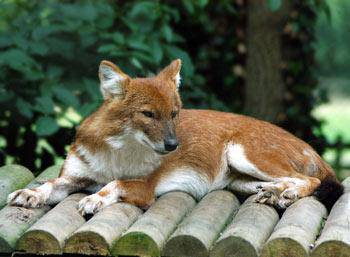

In [ ]:
image


In [ ]:
tf.constant(image)[:2]

<tf.Tensor: shape=(2, 350, 3), dtype=uint8, numpy=
array([[[ 89, 137,  89],
        [ 76, 124,  76],
        [ 63, 111,  61],
        ...,
        [ 77, 133,  86],
        [ 76, 134,  86],
        [ 76, 134,  86]],

       [[ 72, 119,  75],
        [ 67, 114,  68],
        [ 63, 110,  64],
        ...,
        [ 75, 131,  84],
        [ 74, 132,  84],
        [ 74, 132,  84]]], dtype=uint8)>

In [ ]:
#Define image size
IMG_SIZE = 224

def process_image(image_path, IMG_SIZE = 224):
  """
  Take an imagefile path and turns an image into a tensor of fixed size

  """
  # Read in an image file
  image = tf.io.read_file(image_path)
 # Turn the jpeg image into numerical Tensor with 3 colour channels (Red, Green, Blue)
  image = tf.image.decode_jpeg(image, channels = 3)
  #convert the colour channel values from 0-255 to 0-1 values
  image = tf.image.convert_image_dtype(image, tf.float32)
 # resizing the image
  image = tf.image.resize(image, size = [IMG_SIZE, IMG_SIZE])
  return image



##Turning Data Into Batches

In [ ]:
#Function to return a tuple of tensors

def get_image_label(image_path, label):
  """
  this function takes image file path name and the associated label,
  processes the image and returns a tuple of (image, label)).

  """
  image = process_image(image_path)
  return image, label

In [ ]:
(process_image(X[42]), y[42] )

(<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
 array([[[0.3264178 , 0.5222886 , 0.3232816 ],
         [0.2537167 , 0.44366494, 0.24117759],
         [0.25699762, 0.4467087 , 0.23893751],
         ...,
         [0.29325107, 0.5189916 , 0.3215547 ],
         [0.29721776, 0.52466875, 0.33030328],
         [0.2948505 , 0.5223015 , 0.33406618]],
 
        [[0.25903144, 0.4537807 , 0.27294815],
         [0.24375686, 0.4407019 , 0.2554778 ],
         [0.2838985 , 0.47213382, 0.28298813],
         ...,
         [0.2785345 , 0.5027992 , 0.31004712],
         [0.28428748, 0.5108719 , 0.32523635],
         [0.28821915, 0.5148036 , 0.32916805]],
 
        [[0.20941195, 0.40692952, 0.25792548],
         [0.24045378, 0.43900946, 0.2868911 ],
         [0.29001117, 0.47937486, 0.32247734],
         ...,
         [0.26074055, 0.48414773, 0.30125174],
         [0.27101526, 0.49454468, 0.32096273],
         [0.27939945, 0.5029289 , 0.32934693]],
 
        ...,
 
        [[0.00634795, 0.03442048

NOW we are going to turn data into tuples of tensors in the form (image, label). Lets make a function to turn all of our data (x & y) into batches!

In [ ]:
#Define batch size to 32
BATCH_SIZE = 32

def create_data_batches(X, y = None, batch_size = BATCH_SIZE, valid_data = False, test_data = False):
  """
  Creates batches of data out of image (x) and label (y) pairs.
  Shuffles the data if it's training but shuffle if its validation data.
  Also accepts test data as input (no labels).
  """
  if test_data:
    print("Creating test data batches...")
    data = tf.data.Dataset.from_tensor_slices(tf.constant(X))
    data_batch = data.map(process_image).batch(BATCH_SIZE)
    return data_batch
  #if data is a validation set dont suffle it.
  elif valid_data:
    print("Creating validation data batches...")
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X), tf.constant(y)))
    data_batch = data.map(get_image_label).batch(BATCH_SIZE)
    return data_batch
  else:
    print("Creating for training data batches...")
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X),tf.constant(y)))
    #Shuffling pathnames and labels before mapping image processor function is faster than shuffling after it.
    data = data.shuffle(buffer_size = len(X))
    data = data.map(get_image_label)
    data_batch = data.batch(BATCH_SIZE)
    return data_batch


In [ ]:
train_data = create_data_batches(X_train, y_train)
val_data = create_data_batches(X_val,y_val, valid_data = True)

Creating for training data batches...
Creating validation data batches...


In [ ]:
# attributes of our data batches
train_data.element_spec, val_data.element_spec

((TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 120), dtype=tf.bool, name=None)),
 (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 120), dtype=tf.bool, name=None)))

##Visualizing Data Batches

In [ ]:
import matplotlib.pyplot as plt

def show_25_images(images, labels):
  """
  Displays a plot of 25 images and their labels form a data batch
  """
  plt.figure(figsize = (15, 15))

  for i in range(25):
    ax = plt.subplot(5, 5, i+1)
    plt.imshow(images[i])
    plt.title(unique_breeds[labels[i].argmax()])
    plt.axis("off")


In [ ]:
train_data

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))>

In [ ]:
train_images, train_labels = next(train_data.as_numpy_iterator())
len(train_images), len(train_labels)
#because our batch isze was 32

(32, 32)

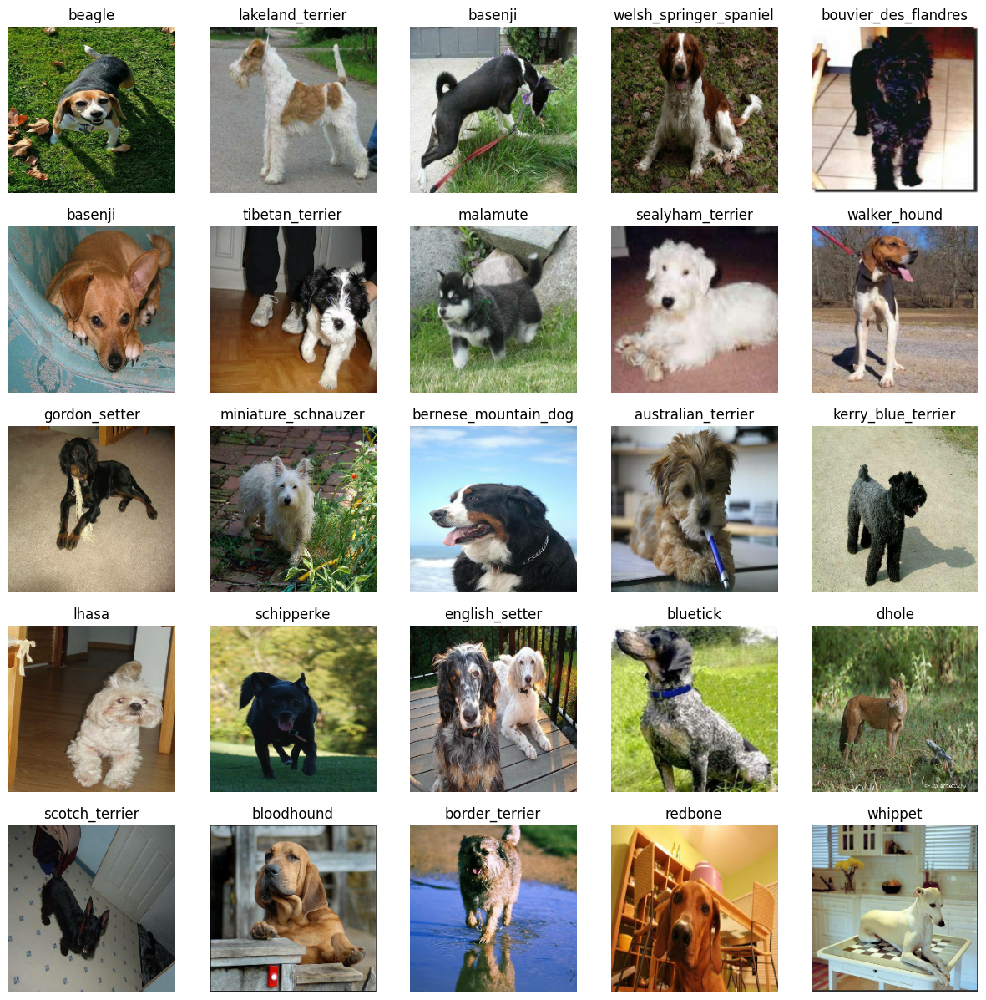

In [ ]:
show_25_images(train_images, train_labels)

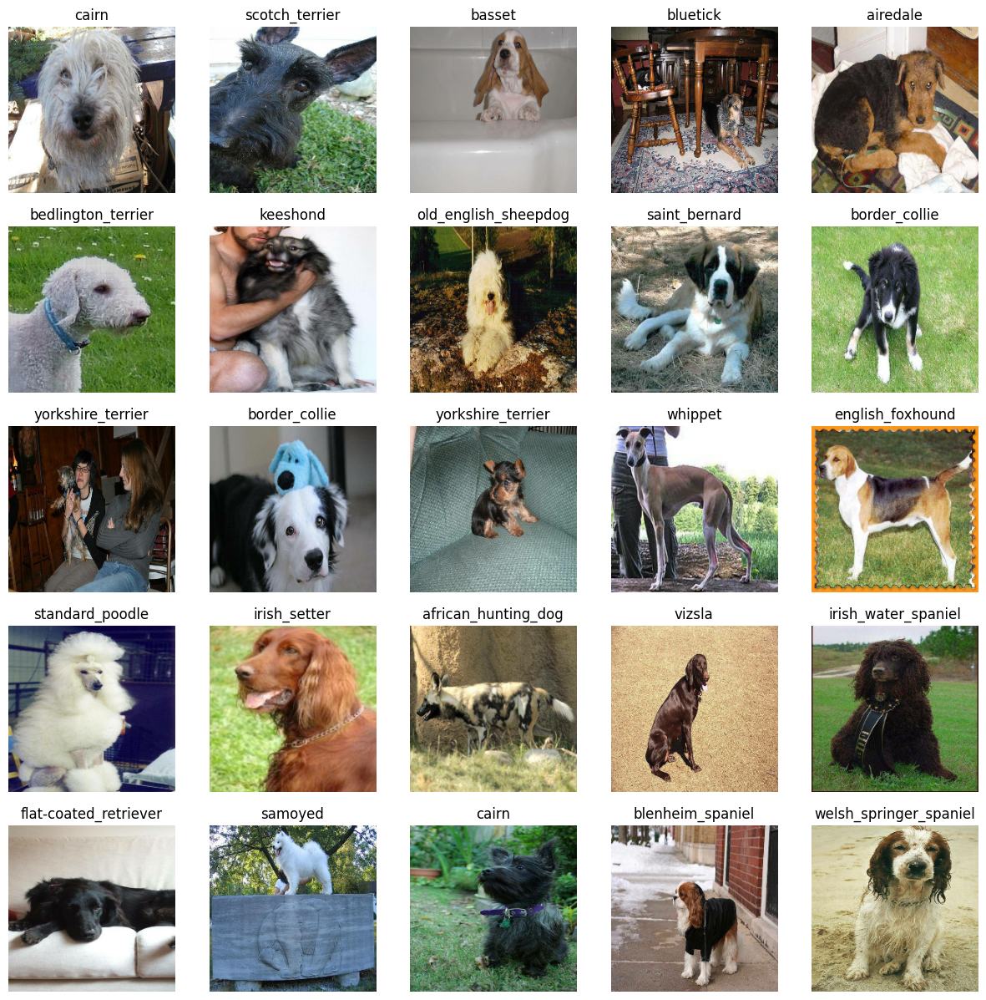

In [ ]:
##Visualizing validation data
valid_images, valid_labels = next(val_data.as_numpy_iterator())
show_25_images(valid_images, valid_labels)

## BUILDING A MODEL
Before we build model , there are a few things we need to define:
* The input shape (our images, in the form of Tensors) to our model.

* The outpjt shape(image lables, in form of Tensors) of our model.

* The URL of the model we want to use.

In [ ]:
INPUT_SHAPE = [None, IMG_SIZE , IMG_SIZE, 3] # batch, rows or height, width or cols, colour channels in each
OUTPUT_SHAPE = len(unique_breeds)
# Setup model URL from Tensorflow Hub
MODEL_URL = "https://tfhub.dev/google/imagenet/mobilenet_v2_130_224/classification/4"

Now we got our inputs, outputs and model ready to go. putting them together into a keras deep learning model.
knowing this , let's create a function:

* Takes the input shape, output shape and the model we've chosen as parameters.
* Defines the layers in a keras model in sequential fashion (do this first, then this, then that)
* compile the model
* Builds the model
* Returns the model.


In [ ]:
#Create a function which builds a keras model
def create_model(input_shape = INPUT_SHAPE, output_shape = OUTPUT_SHAPE, model_url = MODEL_URL):
  print("Building model with:", MODEL_URL)

  #Setup the model layers
  model = tf.keras.Sequential([
    hub.KerasLayer(MODEL_URL), # Layer1 input layer
    tf.keras.layers.Dense(units = OUTPUT_SHAPE, # Layer2 output layer
                          activation = "softmax")
  ])

  model.compile(
      loss = tf.losses.CategoricalCrossentropy(),
      optimizer = tf.keras.optimizers.Adam(),
      metrics = ["accuracy"]
  )
  model.build(INPUT_SHAPE)
  return model


In [ ]:
model = create_model()
model.summary()

Building model with: https://tfhub.dev/google/imagenet/mobilenet_v2_130_224/classification/4
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 1001)              5432713   
                                                                 
 dense (Dense)               (None, 120)               120240    
                                                                 
Total params: 5552953 (21.18 MB)
Trainable params: 120240 (469.69 KB)
Non-trainable params: 5432713 (20.72 MB)
_________________________________________________________________


## Creating callbacks

callbacks are helper functions a model during training to do such things such as save its progress or stop training early if a model stops improving.

Creating 2 callbacks , one for tensorboard which helps track our models progress and another early stopping which prevents our model from training for too long.

## TensorBoard Callback
To set tensorboard callback, we need 3 things
1. Load the tensorboard notebook extensions
2. create a TensorBoard callback which is able to save logs to directory and pass it our model's fit() function.
3. Visualize our models training los with the standard %tensorboard magic function .

In [ ]:
import tensorboard
# Load TensorBoard notebook extension
%load_ext tensorboard

In [ ]:
import datetime


# Function for a tensorboard callback
def create_tensorboard_callback():
  # Using %m for month and %M for minutes
  logdir = os.path.join("/content/drive/MyDrive/dog_breed_data/logs",
                        datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

  return tf.keras.callbacks.TensorBoard(logdir)

### Early stopping callback

Early stopping help stop our model from overfitting by stopping training if certain evaluation metric stops improving.



In [ ]:
stopping_callback = tf.keras.callbacks.EarlyStopping(monitor = "val_accuracy",
                                                     patience = 3)

## Traning a model (on a subset of data)

Our first model is going to train on 1000 images, to make sure everything is working.

In [ ]:
NUM_EPOCHS = 100 #@param{type:"slider", min:10, max:100, step:10}

In [ ]:
#check to make sure if running on a gpu
if tf.config.list_physical_devices('GPU'):
  print("yes, using gpu")
else:
  print("GPU not found")

GPU not found


Creating a function which trains a model
.
* create a model using "create_model()"
* Setup a TensorBoard callback using "create_tensorboard_callback()"
* call the fit() function on our model passing it the training data, validation data, number of epoches and callbacks.
* return the model

In [ ]:
def train_model():
  """
  Trains a given model and returns a trained version
  """
  #create a model
  model = create_model()

  #create new TensorBoard session everytime we train a model
  tensorboard = create_tensorboard_callback()

  # Fit the model to the data
  model.fit(x = train_data,
            epochs = NUM_EPOCHS,
            validation_data = val_data,
            validation_freq = 1,
            callbacks = [tensorboard, stopping_callback])
  return model

In [ ]:
model = train_model()

Building model with: https://tfhub.dev/google/imagenet/mobilenet_v2_130_224/classification/4
Epoch 1/100
25/25 [==============================] - 358s 14s/step - loss: 4.5468 - accuracy: 0.1050 - val_loss: 3.3874 - val_accuracy: 0.2150
Epoch 2/100
25/25 [==============================] - 55s 2s/step - loss: 1.5910 - accuracy: 0.6988 - val_loss: 2.0846 - val_accuracy: 0.5400
Epoch 3/100
25/25 [==============================] - 64s 3s/step - loss: 0.5463 - accuracy: 0.9475 - val_loss: 1.6722 - val_accuracy: 0.5750
Epoch 4/100
25/25 [==============================] - 53s 2s/step - loss: 0.2412 - accuracy: 0.9875 - val_loss: 1.5032 - val_accuracy: 0.6300
Epoch 5/100
25/25 [==============================] - 66s 3s/step - loss: 0.1429 - accuracy: 0.9950 - val_loss: 1.4159 - val_accuracy: 0.6450
Epoch 6/100
25/25 [==============================] - 63s 3s/step - loss: 0.1001 - accuracy: 0.9987 - val_loss: 1.3750 - val_accuracy: 0.6450
Epoch 7/100
25/25 [==============================] - 53s 2s

Since the model is overfitting because its performing far better on the training dataset than the validation dataset. we use few ways to prevent the model overfitting in deep learning neural networks.

Checking the TensorBoard Logs

The TensorBoard magic function (%tensorboard) will access the logs directory we created earlier and visualize its contents.

In [55]:
%tensorboard --logdir /content/drive/MyDrive/dog_breed_data/logs

<IPython.core.display.Javascript object>

 ## Making and evaluating predictions using trained model

In [57]:
val_data

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))>

In [59]:
predictions = model.predict(val_data, verbose = 1)
predictions

7/7 [==============================] - 14s 2s/step


array([[7.35987385e-04, 8.51753139e-05, 9.77524789e-04, ...,
        3.31791671e-04, 2.65343861e-05, 5.36718313e-03],
       [4.67577018e-03, 1.77776441e-04, 4.11712304e-02, ...,
        7.31786364e-04, 2.89176614e-03, 9.38101657e-05],
       [3.85289241e-05, 5.60403078e-06, 7.76665092e-06, ...,
        4.63553943e-06, 4.43188901e-06, 1.07699634e-04],
       ...,
       [9.48317211e-06, 9.97089373e-05, 4.91235769e-05, ...,
        3.39074395e-05, 1.33620255e-04, 2.79386324e-04],
       [1.18932978e-03, 3.12125048e-04, 8.96192942e-05, ...,
        2.10112936e-04, 2.17706565e-05, 4.49956907e-03],
       [2.30310936e-04, 8.91918389e-05, 5.78535779e-04, ...,
        4.67922492e-03, 7.44620105e-04, 5.93237564e-05]], dtype=float32)

In [61]:
predictions.shape

(200, 120)

In [62]:
len(y_val)

200

In [63]:
len(unique_breeds)

120

In [64]:
predictions[0]

array([7.35987385e-04, 8.51753139e-05, 9.77524789e-04, 3.18027778e-05,
       4.50014399e-04, 4.33629612e-05, 6.96681300e-03, 1.30816502e-03,
       1.48361083e-04, 1.05295249e-03, 6.45246939e-04, 1.36144939e-04,
       2.99154519e-04, 1.66793561e-05, 1.70554651e-03, 1.04373216e-03,
       4.09505083e-05, 4.42771733e-01, 8.87504430e-05, 2.09498285e-05,
       6.04185974e-04, 3.90221830e-05, 8.05302807e-06, 4.11992893e-03,
       2.09710179e-05, 2.11338629e-04, 7.24415630e-02, 1.45936065e-04,
       4.51354543e-04, 2.46562384e-04, 5.72812642e-05, 3.22193326e-03,
       1.69611027e-04, 4.73734144e-06, 1.44042584e-04, 1.41751274e-01,
       4.46826962e-05, 1.26723506e-04, 4.43776553e-05, 6.22788793e-05,
       5.96167694e-04, 3.31688352e-05, 1.14831018e-04, 2.40655849e-04,
       2.13792300e-05, 8.71998491e-05, 1.48990684e-05, 3.09174939e-04,
       3.97922995e-04, 2.03639138e-04, 1.20912923e-03, 2.03403506e-05,
       1.64441255e-04, 6.34028329e-05, 6.79897857e-05, 1.24761873e-05,
      

In [65]:
np.sum(predictions[0])

np.float32(1.0)

In [66]:
index = 0
print(predictions[index])
print(f"Max value (probability of prediction) ; {np.max(predictions[index])}")
print(f"Sum : {np.sum(predictions[index])}")
print(f"Max index: {np.argmax(predictions[index])}")
print(f"Predicted label: {unique_breeds[np.argmax(predictions[index])]}")

[7.35987385e-04 8.51753139e-05 9.77524789e-04 3.18027778e-05
 4.50014399e-04 4.33629612e-05 6.96681300e-03 1.30816502e-03
 1.48361083e-04 1.05295249e-03 6.45246939e-04 1.36144939e-04
 2.99154519e-04 1.66793561e-05 1.70554651e-03 1.04373216e-03
 4.09505083e-05 4.42771733e-01 8.87504430e-05 2.09498285e-05
 6.04185974e-04 3.90221830e-05 8.05302807e-06 4.11992893e-03
 2.09710179e-05 2.11338629e-04 7.24415630e-02 1.45936065e-04
 4.51354543e-04 2.46562384e-04 5.72812642e-05 3.22193326e-03
 1.69611027e-04 4.73734144e-06 1.44042584e-04 1.41751274e-01
 4.46826962e-05 1.26723506e-04 4.43776553e-05 6.22788793e-05
 5.96167694e-04 3.31688352e-05 1.14831018e-04 2.40655849e-04
 2.13792300e-05 8.71998491e-05 1.48990684e-05 3.09174939e-04
 3.97922995e-04 2.03639138e-04 1.20912923e-03 2.03403506e-05
 1.64441255e-04 6.34028329e-05 6.79897857e-05 1.24761873e-05
 2.38791603e-04 2.16302206e-03 2.51596677e-04 6.99675903e-02
 5.94007979e-05 7.13107365e-05 5.27039636e-04 1.24413811e-04
 4.55035595e-04 3.919031